# Model Iteration Performance Assessment

## Metrics Chosen

FID (Fréchet Inception Distance) and KID (Kernel Inception Distance) are key metrics for evaluating Generative Adversarial Networks (GANs) by comparing the distributions of real and generated images. They measure both image quality (fidelity) and variety (diversity), with lower scores indicating better, more realistic output.

## Frameworks


In [15]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
from natsort import natsorted
import os

## Config

In [16]:
MAIN_DIR = r"GAN/outputs"

## Reading Data

In [17]:
dataframes_dict = {}
full_name = {}

for folder in os.listdir(MAIN_DIR):
    if "g7" in folder: continue
    folder_path = os.path.join(MAIN_DIR, folder, "metrics")
    if os.path.isdir(folder_path):
        # extract the two dataframes
        df1 = pd.read_csv(os.path.join(folder_path, "fid_kid_history.csv"))
        df2 = pd.read_csv(os.path.join(folder_path, "training_history.csv"))
        # store in dictionary
        dataframes_dict[folder[:3]] = (df1, df2)
        full_name[folder[:3]] = folder

dataframes_dict = dict(natsorted(dataframes_dict.items()))

print(dataframes_dict.keys())
print(full_name.values())

dict_keys(['g0_', 'g1_', 'g2_', 'g3_', 'g4_', 'g5_', 'g6_', 'g8_', 'g9_', 'g10'])
dict_values(['g0_baseline_instrumented_with_KID', 'g10_fastgan_cropped', 'g1_more_data', 'g2_discriminator_balancing', 'g3_ema_generator', 'g4_spectralnorm_discriminator', 'g5_full_data_ema_bestfid', 'g6_facecrop_regularized', 'g8_better_discriminator', 'g9_fastgan'])


## Training Loss Evolution

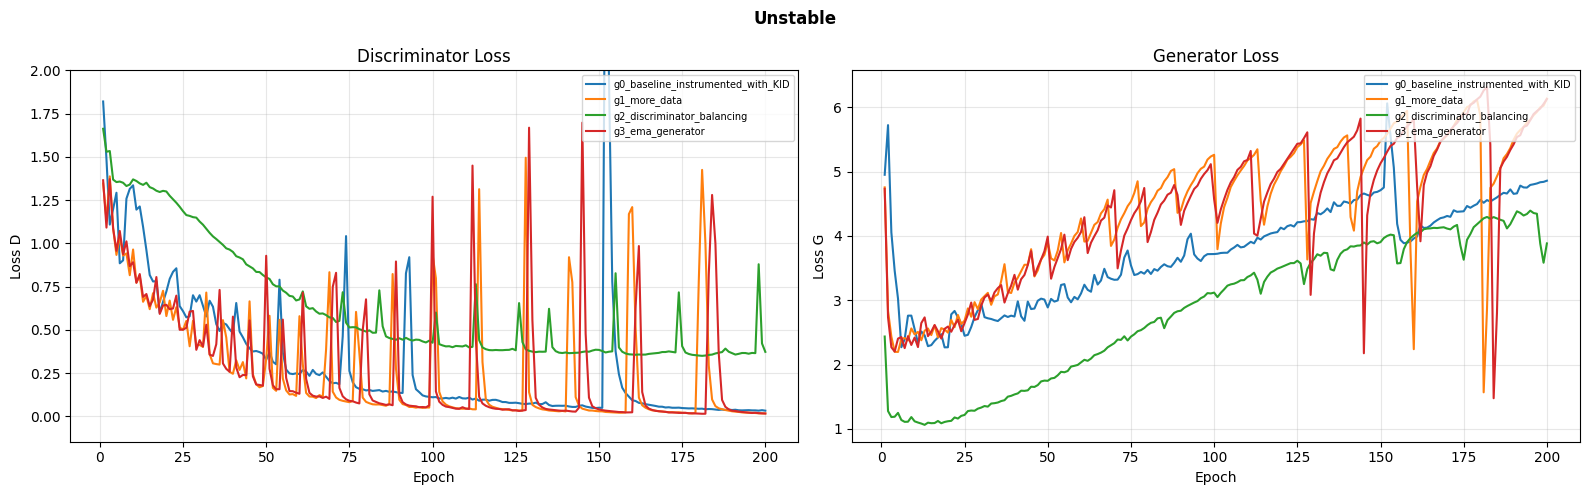

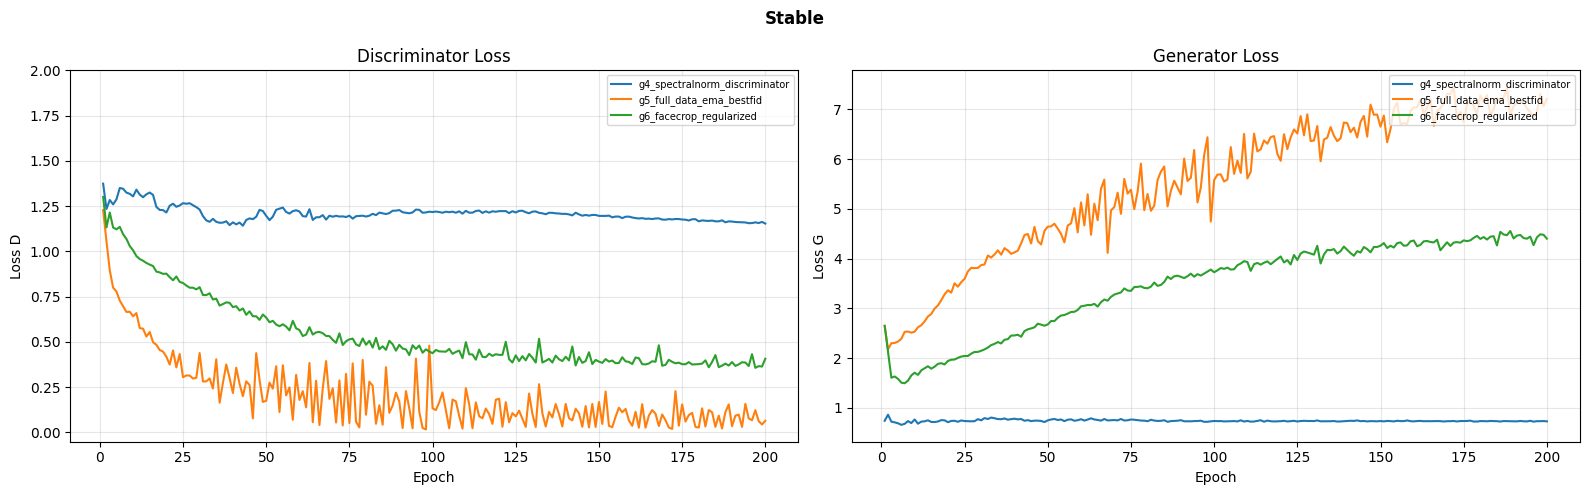

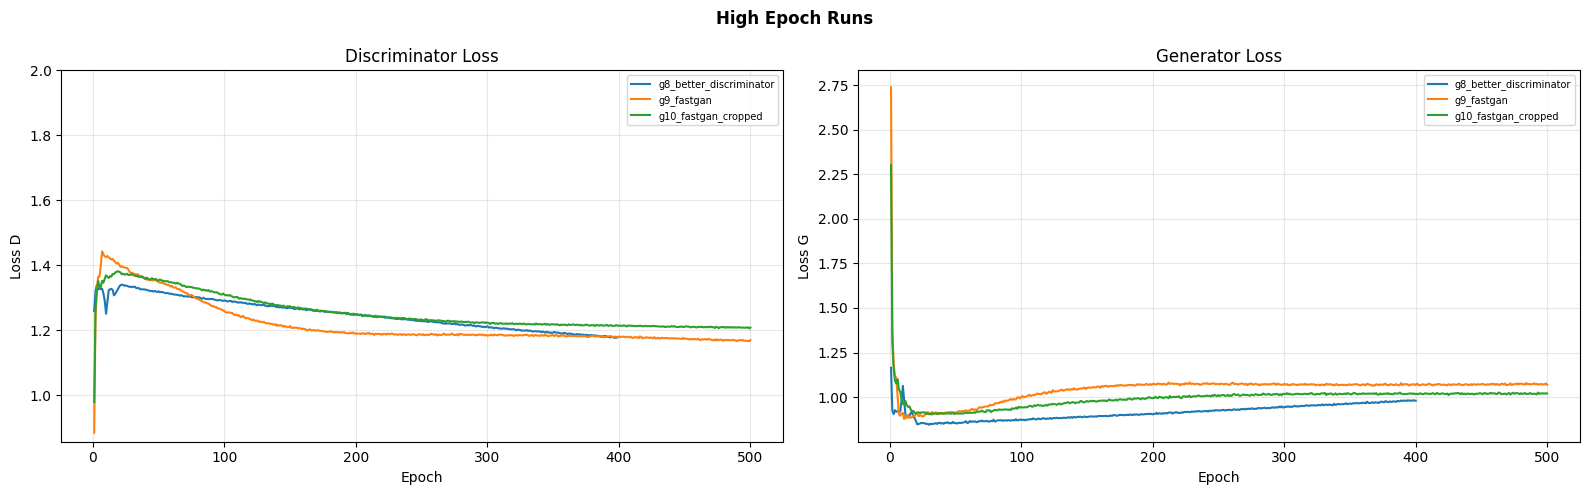

In [18]:
colors = plt.cm.tab10.colors

all_items = list(dataframes_dict.items())
groups    = [all_items[:4], all_items[4:-3], all_items[-3:]]
subtitles = ["Unstable", "Stable", "High Epoch Runs"]

for group, subtitle in zip(groups, subtitles):
    fig, (ax_d, ax_g) = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(subtitle, fontsize=12, fontweight="bold")

    for (key, (df_metrics, df_train)), color in zip(group, colors):
        label = full_name[key]
        ax_d.plot(df_train["epoch"], df_train["loss_d"], label=label, color=color)
        ax_g.plot(df_train["epoch"], df_train["loss_g"], label=label, color=color)

    ax_d.set_title("Discriminator Loss")
    ax_d.set_xlabel("Epoch"); ax_d.set_ylabel("Loss D")
    ax_d.set_ylim(top=2.0)
    ax_d.legend(fontsize=7, loc="upper right"); ax_d.grid(True, alpha=0.3)

    ax_g.set_title("Generator Loss")
    ax_g.set_xlabel("Epoch"); ax_g.set_ylabel("Loss G")
    ax_g.legend(fontsize=7, loc="upper right"); ax_g.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## Training Stability (Rolling Volatility)

A rolling standard deviation of the discriminator and generator losses over a sliding window of epochs.
High volatility means the training was erratic; low and decreasing volatility means the run settled into a stable equilibrium.
This is a better stability signal than the raw loss curves because it strips out the level and focuses purely on variability.

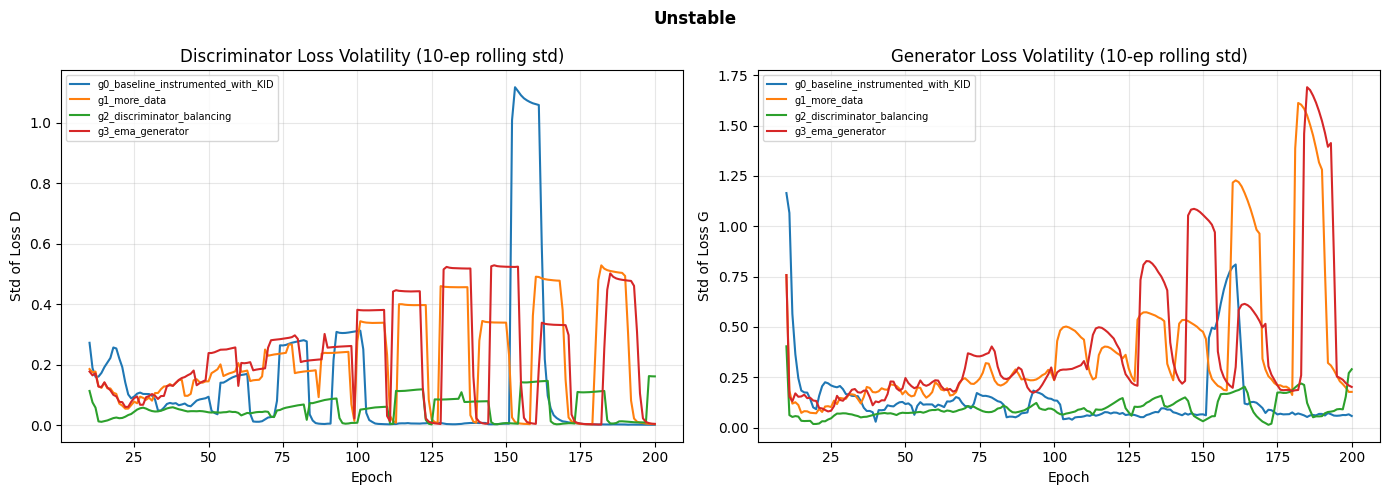

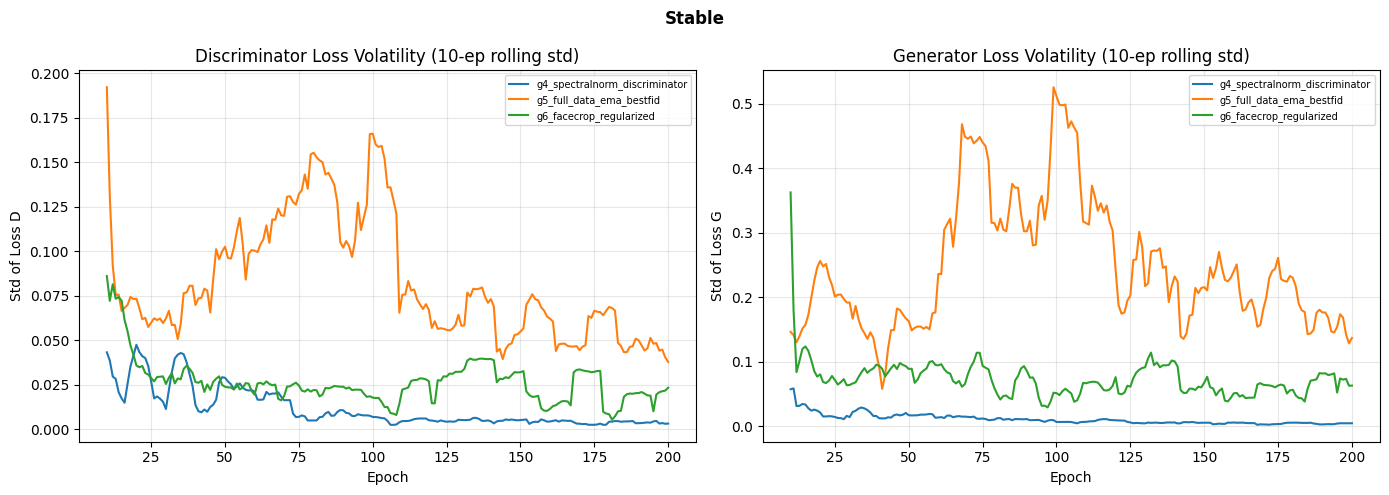

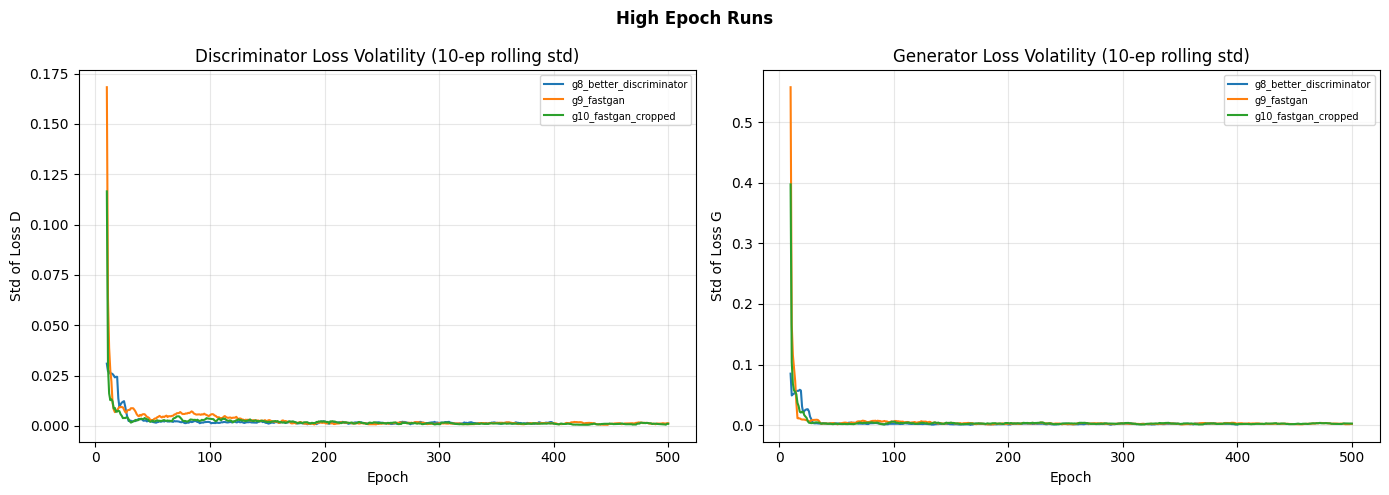

In [19]:
window = 10

all_items = list(dataframes_dict.items())
groups    = [all_items[:4], all_items[4:-3], all_items[-3:]]
subtitles = ["Unstable", "Stable", "High Epoch Runs"]

for group, subtitle in zip(groups, subtitles):
    fig, (ax_d, ax_g) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(subtitle, fontsize=12, fontweight="bold")

    for (key, (df_metrics, df_train)), color in zip(group, colors):
        label = full_name[key]
        ax_d.plot(df_train["epoch"], df_train["loss_d"].rolling(window).std(), label=label, color=color)
        ax_g.plot(df_train["epoch"], df_train["loss_g"].rolling(window).std(), label=label, color=color)

    ax_d.set_title(f"Discriminator Loss Volatility ({window}-ep rolling std)")
    ax_d.set_xlabel("Epoch"); ax_d.set_ylabel("Std of Loss D")
    ax_d.legend(fontsize=7); ax_d.grid(True, alpha=0.3)

    ax_g.set_title(f"Generator Loss Volatility ({window}-ep rolling std)")
    ax_g.set_xlabel("Epoch"); ax_g.set_ylabel("Std of Loss G")
    ax_g.legend(fontsize=7); ax_g.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## Discriminator-Generator Balance 

These three signals come directly from the discriminator's outputs:

- **D(x)**: discriminator confidence on real images, ideally near 1.0 early on, then converging toward 0.5 as the generator improves.
- **D(G(z)) fake**: discriminator confidence on generated images *before* the generator update, should decrease as the generator gets harder to fool.
- **D(G(z)) gen**: discriminator confidence on generated images *after* the generator update, should increase as the generator learns.

A healthy run shows D(x) staying moderate, D(G(z)) fake low, and D(G(z)) gen gradually rising. Collapse or mode drop often shows up here before it appears in the loss curves.

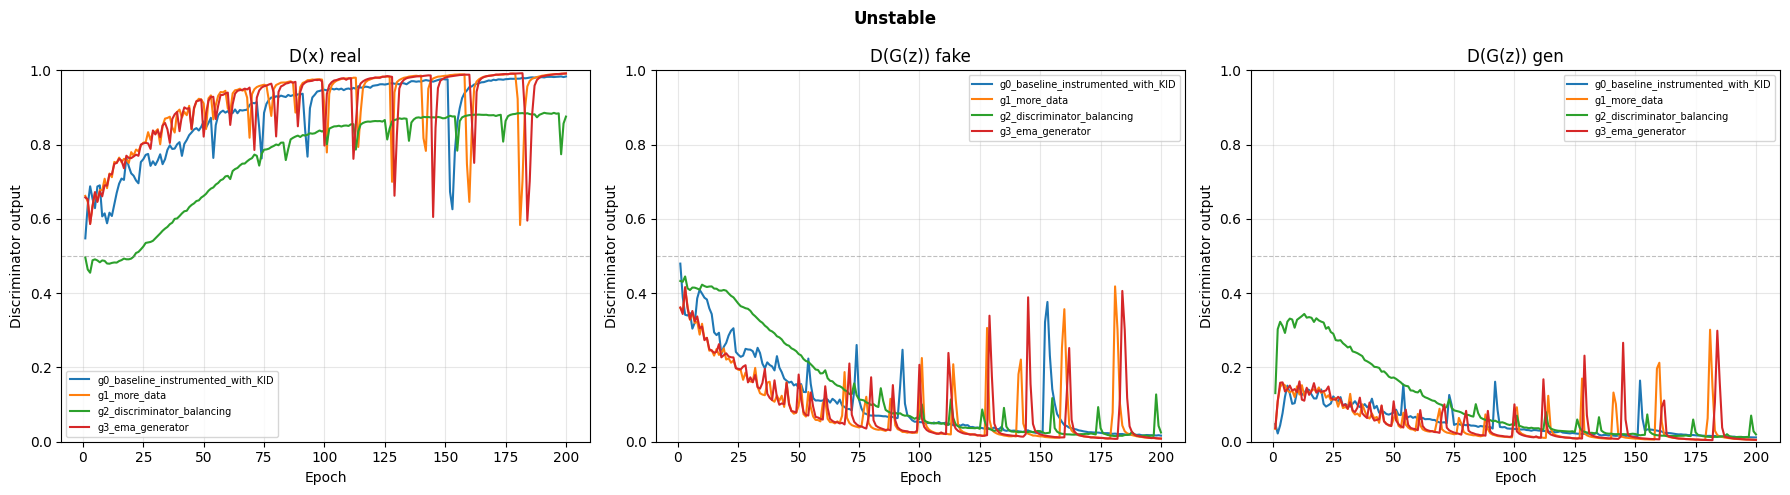

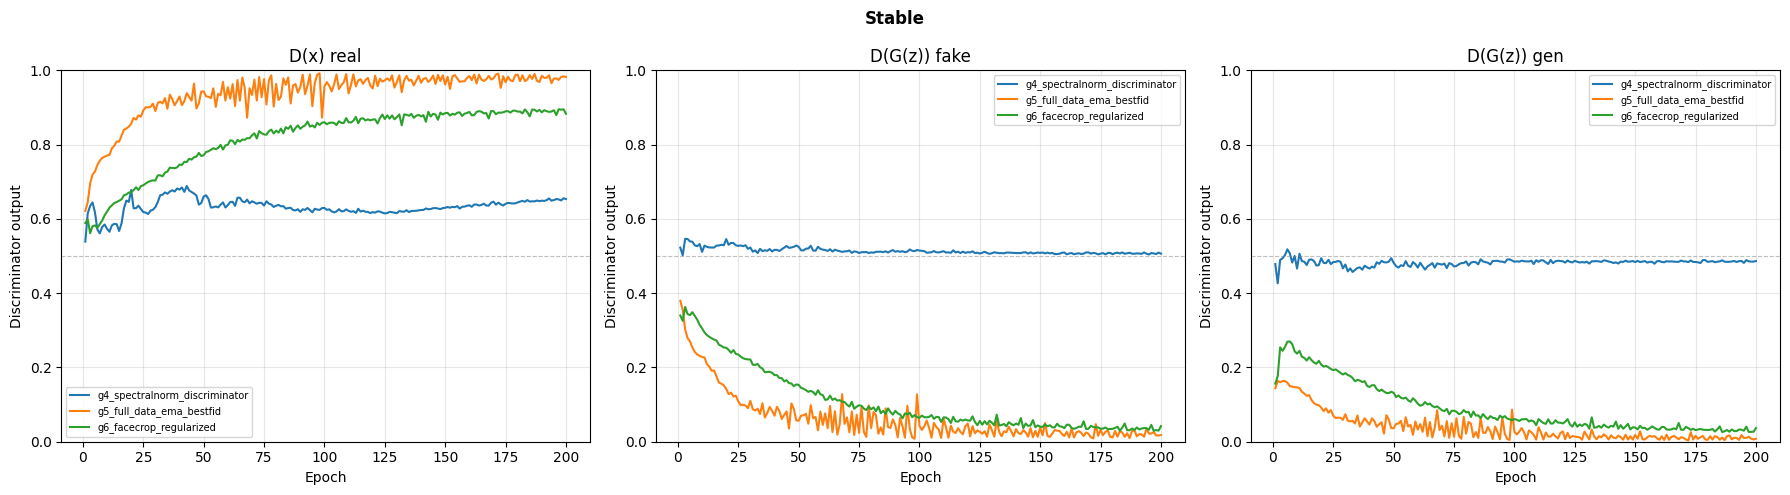

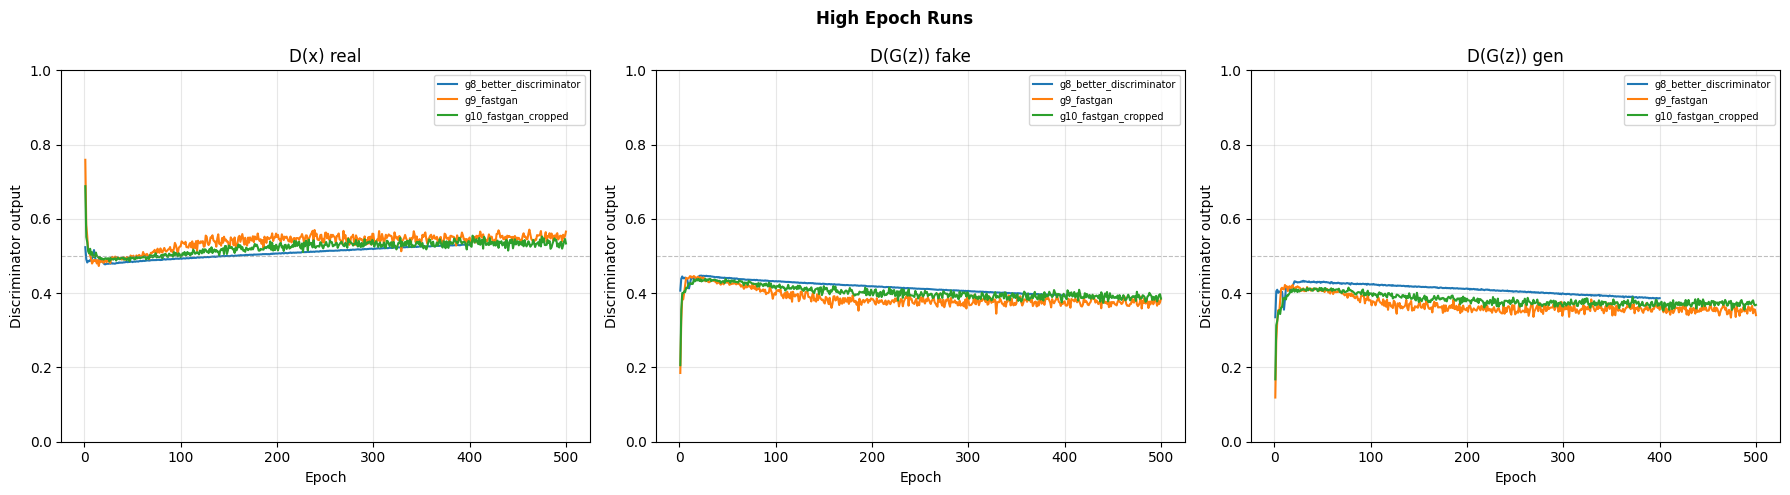

In [20]:
signals = ["D_x", "D_G_z_fake", "D_G_z_gen"]
signal_labels = ["D(x) real", "D(G(z)) fake", "D(G(z)) gen"]

all_items = list(dataframes_dict.items())
groups    = [all_items[:4], all_items[4:-3], all_items[-3:]]
subtitles = ["Unstable", "Stable", "High Epoch Runs"]

for group, subtitle in zip(groups, subtitles):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(subtitle, fontsize=12, fontweight="bold")

    for (key, (df_metrics, df_train)), color in zip(group, colors):
        label = full_name[key]
        for ax, signal in zip(axes, signals):
            ax.plot(df_train["epoch"], df_train[signal], label=label, color=color)

    for ax, sig_label in zip(axes, signal_labels):
        ax.set_title(sig_label)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Discriminator output")
        ax.set_ylim(0, 1)
        ax.axhline(0.5, linestyle="--", color="gray", alpha=0.5, linewidth=0.8)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## Comparing Performance

### Metric Evolution

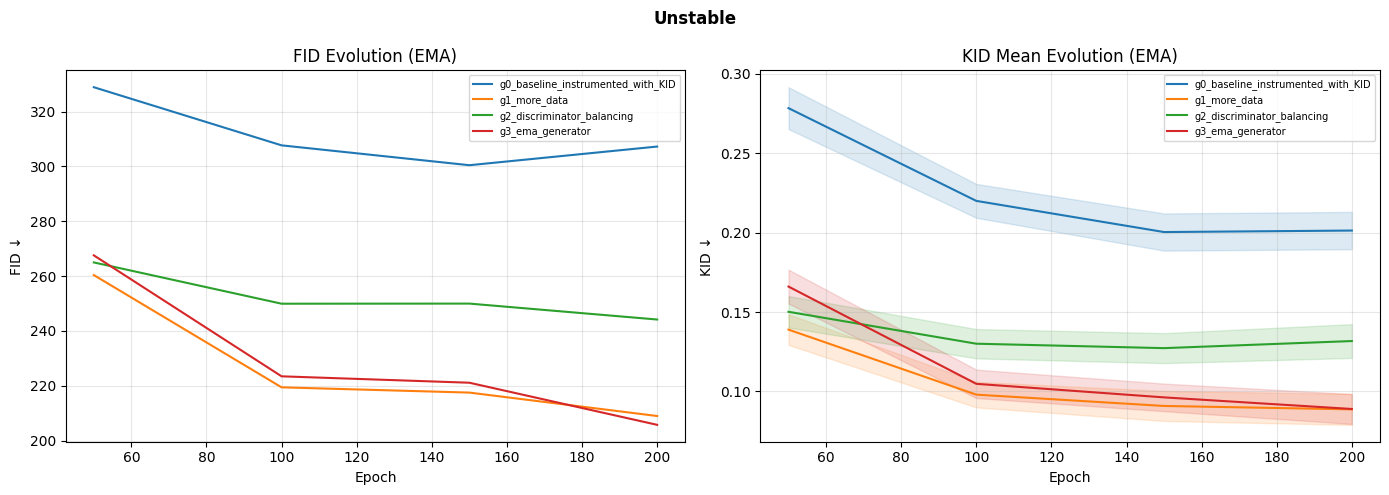

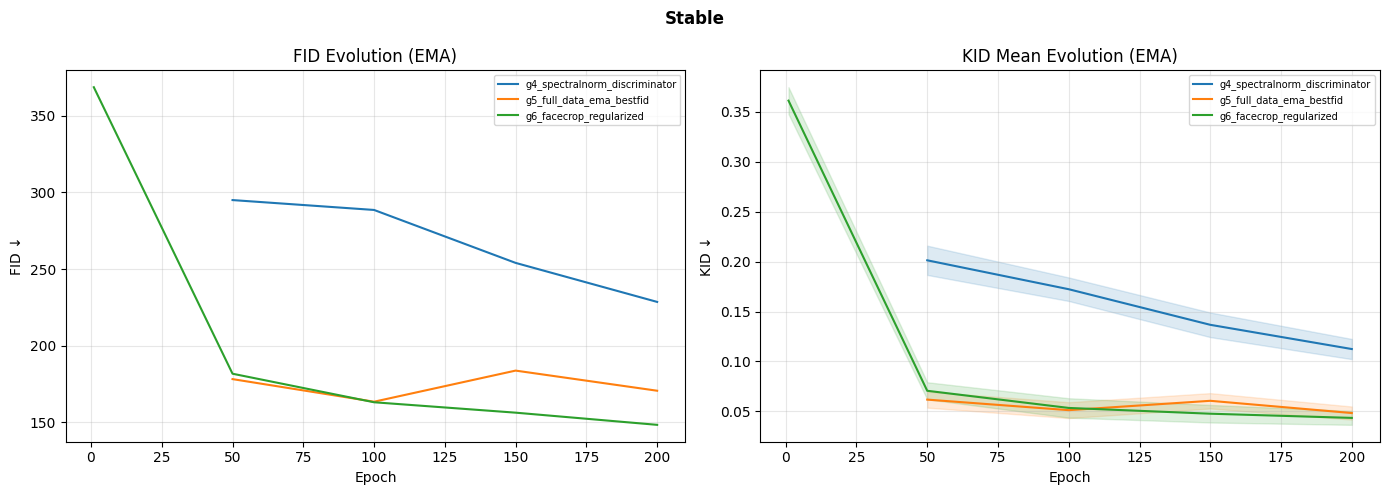

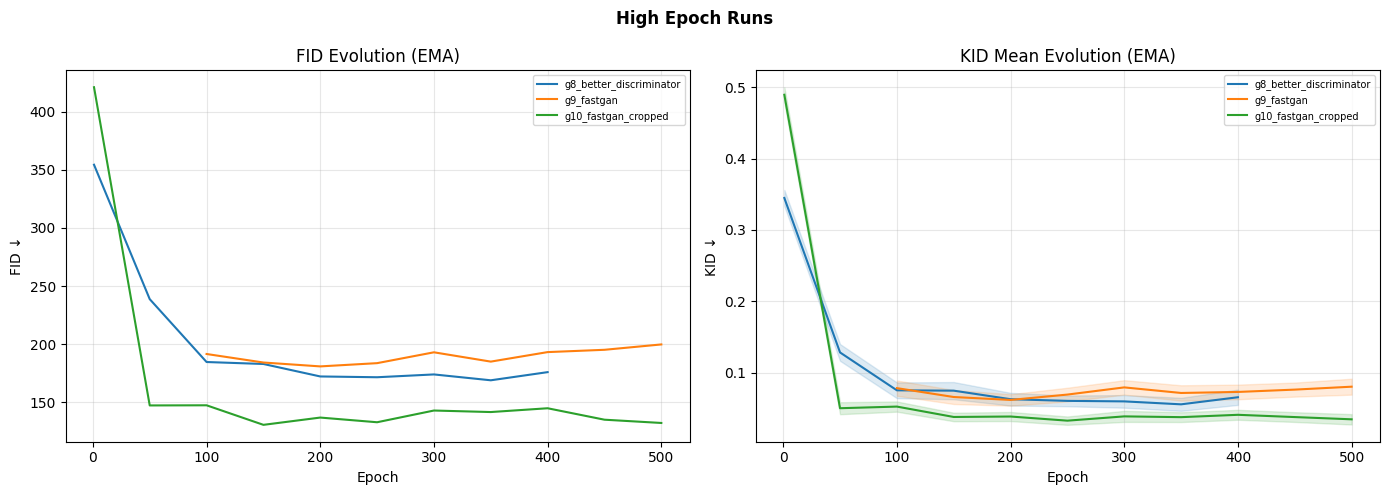

In [21]:
all_items = list(dataframes_dict.items())
groups    = [all_items[:4], all_items[4:-3], all_items[-3:]]
subtitles = ["Unstable", "Stable", "High Epoch Runs"]

for group, subtitle in zip(groups, subtitles):
    fig, (ax_fid, ax_kid) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(subtitle, fontsize=12, fontweight="bold")

    for (key, (df_metrics, df_train)), color in zip(group, colors):
        label = full_name[key]
        df_ema = df_metrics[df_metrics["evaluated_model"] == "ema"] if "evaluated_model" in df_metrics.columns else df_metrics

        ax_fid.plot(df_ema["epoch"], df_ema["fid"], label=label, color=color)
        ax_kid.plot(df_ema["epoch"], df_ema["kid_mean"], label=label, color=color)
        ax_kid.fill_between(
            df_ema["epoch"],
            df_ema["kid_mean"] - df_ema["kid_std"],
            df_ema["kid_mean"] + df_ema["kid_std"],
            alpha=0.15, color=color
        )

    ax_fid.set_title("FID Evolution (EMA)")
    ax_fid.set_xlabel("Epoch"); ax_fid.set_ylabel("FID ↓")
    ax_fid.legend(fontsize=7); ax_fid.grid(True, alpha=0.3)

    ax_kid.set_title("KID Mean Evolution (EMA)")
    ax_kid.set_xlabel("Epoch"); ax_kid.set_ylabel("KID ↓")
    ax_kid.legend(fontsize=7); ax_kid.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

### Model Improvements Assessment

In [40]:
rows = []
for key, (df_metrics, df_train) in dataframes_dict.items():
    df_ema = df_metrics[df_metrics["evaluated_model"] == "ema"] if "evaluated_model" in df_metrics.columns else df_metrics
    last = df_ema.sort_values("epoch").iloc[-1]
    rows.append({
        "run": full_name[key],
        "epoch": int(last["epoch"]),
        "FID": round(last["fid"], 2),
        "KID mean": round(last["kid_mean"], 4),
        "KID std": round(last["kid_std"], 4),
    })

df_summary = pd.DataFrame(rows)


df_summary.style.background_gradient(
    cmap="YlOrRd",
    subset=["FID", "KID mean", "KID std"]
)


,run,epoch,FID,KID mean,KID std
0,g0_baseline_instrumented_with_KID,200,307.240000,0.201300,0.011800
1,g1_more_data,200,208.990000,0.088700,0.009800
2,g2_discriminator_balancing,200,244.180000,0.131700,0.010600
3,g3_ema_generator,200,205.770000,0.088900,0.009400
4,g4_spectralnorm_discriminator,200,228.510000,0.112400,0.010100
5,g5_full_data_ema_bestfid,200,170.490000,0.048300,0.006600
6,g6_facecrop_regularized,200,148.200000,0.043500,0.007000
7,g8_better_discriminator,400,175.990000,0.065500,0.010700
8,g9_fastgan,500,199.800000,0.080300,0.011200
9,g10_fastgan_cropped,500,132.310000,0.034500,0.007300


## Global Plots (Scaled)

In order to improve result observability for comparison purposes, we have applied min-max scaling:


In [23]:
def minmax(s): return (s - s.min()) / (s.max() - s.min())

Due to the line cluttering, unstable runs were made less noticeable as an attempt to improve aesthetic differentiation:

In [31]:
def get_alpha(key): return 1.0 if any(g in key for g in ["g4", "g5", "g6","g8","g9", "g10"]) else 0.30

### Loss

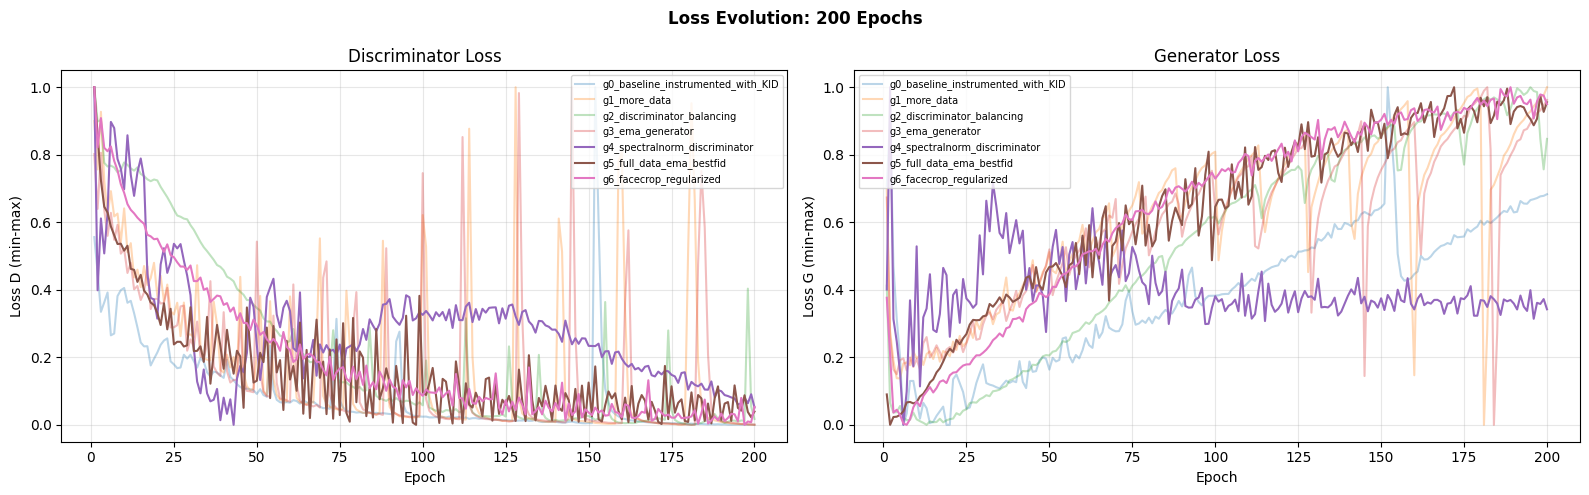

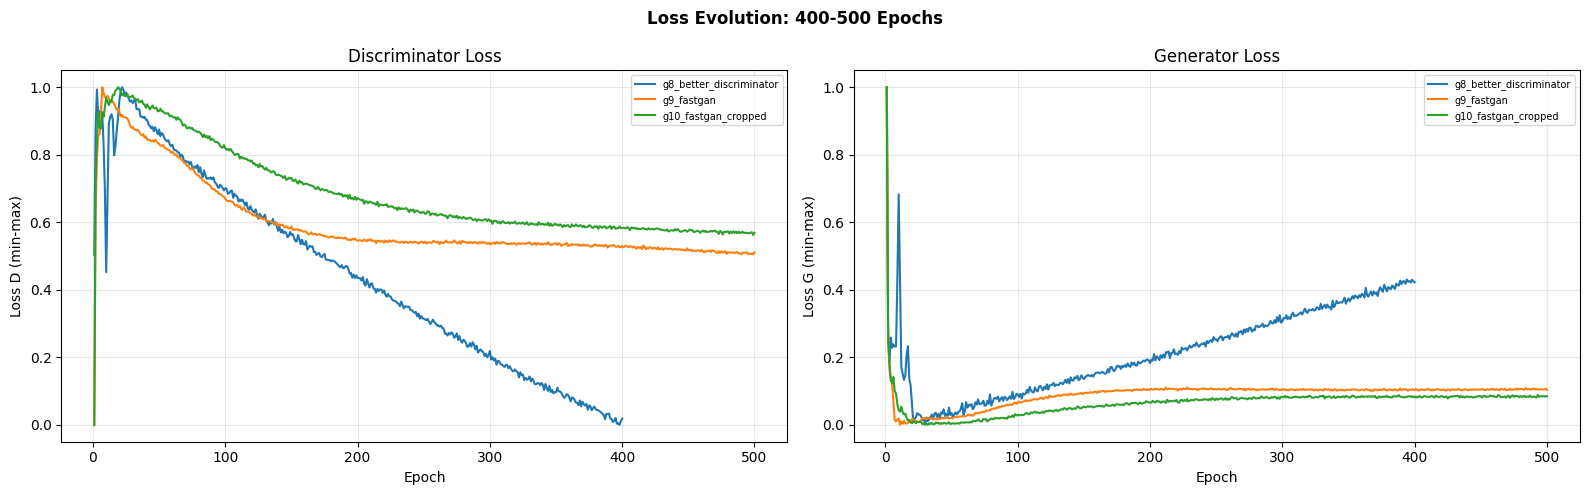

In [32]:
groups    = [all_items[:7], all_items[7:]]
subtitles = ["200 Epochs", "400-500 Epochs"]

for group, subtitle in zip(groups, subtitles):
    fig, (ax_d, ax_g) = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f"Loss Evolution: {subtitle}", fontsize=12, fontweight="bold")

    for (key, (df_metrics, df_train)), color in zip(group, colors):
        alpha = get_alpha(key)
        ax_d.plot(df_train["epoch"], minmax(df_train["loss_d"]), label=full_name[key], color=color, alpha=alpha)
        ax_g.plot(df_train["epoch"], minmax(df_train["loss_g"]), label=full_name[key], color=color, alpha=alpha)

    ax_d.set_title("Discriminator Loss"); ax_d.set_xlabel("Epoch"); ax_d.set_ylabel("Loss D (min-max)")
    ax_d.legend(fontsize=7, loc="upper right"); ax_d.grid(True, alpha=0.3)
    ax_g.set_title("Generator Loss"); ax_g.set_xlabel("Epoch"); ax_g.set_ylabel("Loss G (min-max)")
    ax_g.legend(fontsize=7); ax_g.grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()

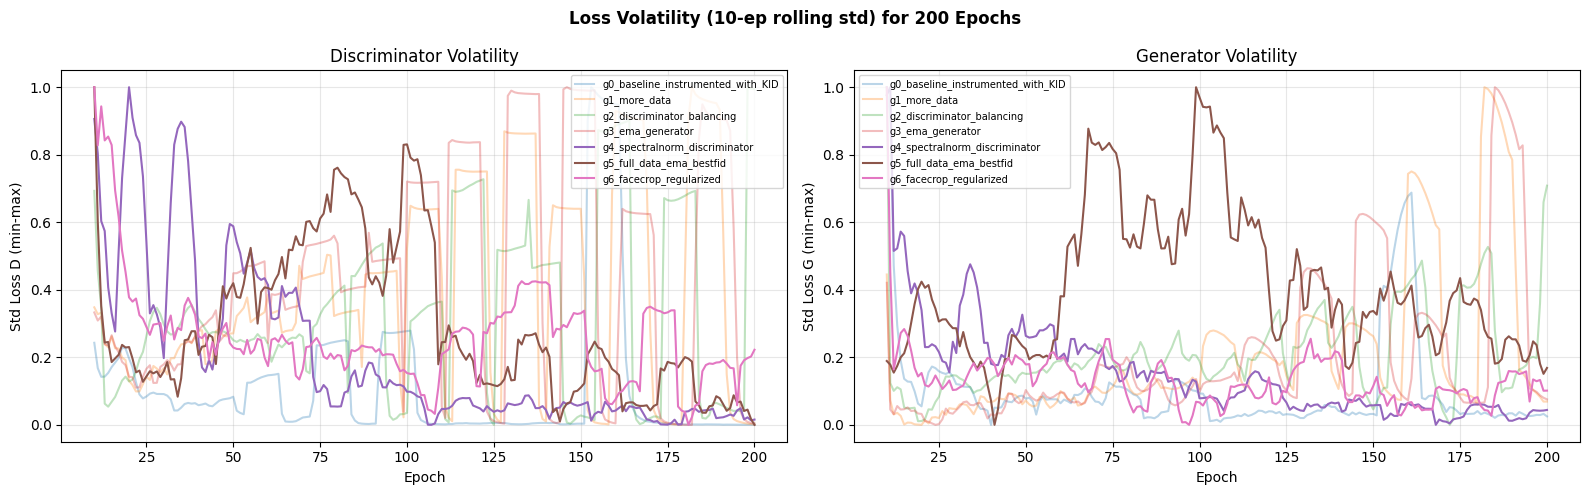

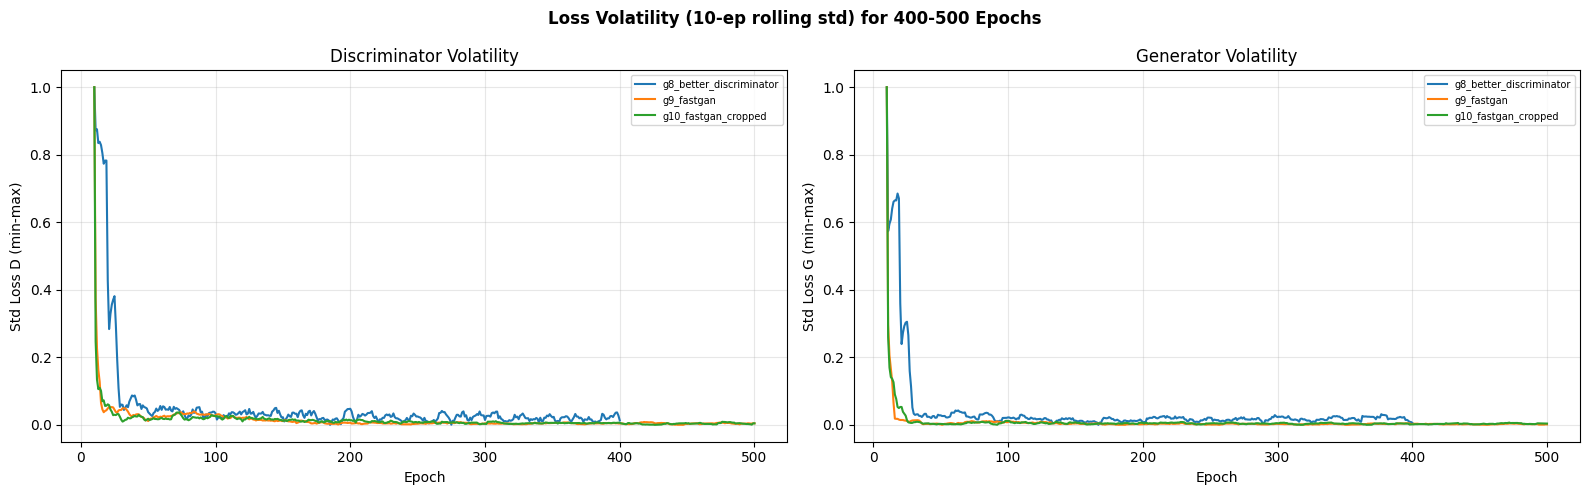

In [33]:
window = 10

for group, subtitle in zip(groups, subtitles):
    fig, (ax_d, ax_g) = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f"Loss Volatility ({window}-ep rolling std) for {subtitle}", fontsize=12, fontweight="bold")

    for (key, (df_metrics, df_train)), color in zip(group, colors):
        alpha = get_alpha(key)
        roll_d = df_train["loss_d"].rolling(window).std()
        roll_g = df_train["loss_g"].rolling(window).std()
        ax_d.plot(df_train["epoch"], minmax(roll_d), label=full_name[key], color=color, alpha=alpha)
        ax_g.plot(df_train["epoch"], minmax(roll_g), label=full_name[key], color=color, alpha=alpha)

    ax_d.set_title("Discriminator Volatility"); ax_d.set_xlabel("Epoch"); ax_d.set_ylabel("Std Loss D (min-max)")
    ax_d.legend(fontsize=7, loc="upper right"); ax_d.grid(True, alpha=0.3)
    ax_g.set_title("Generator Volatility"); ax_g.set_xlabel("Epoch"); ax_g.set_ylabel("Std Loss G (min-max)")
    ax_g.legend(fontsize=7); ax_g.grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()

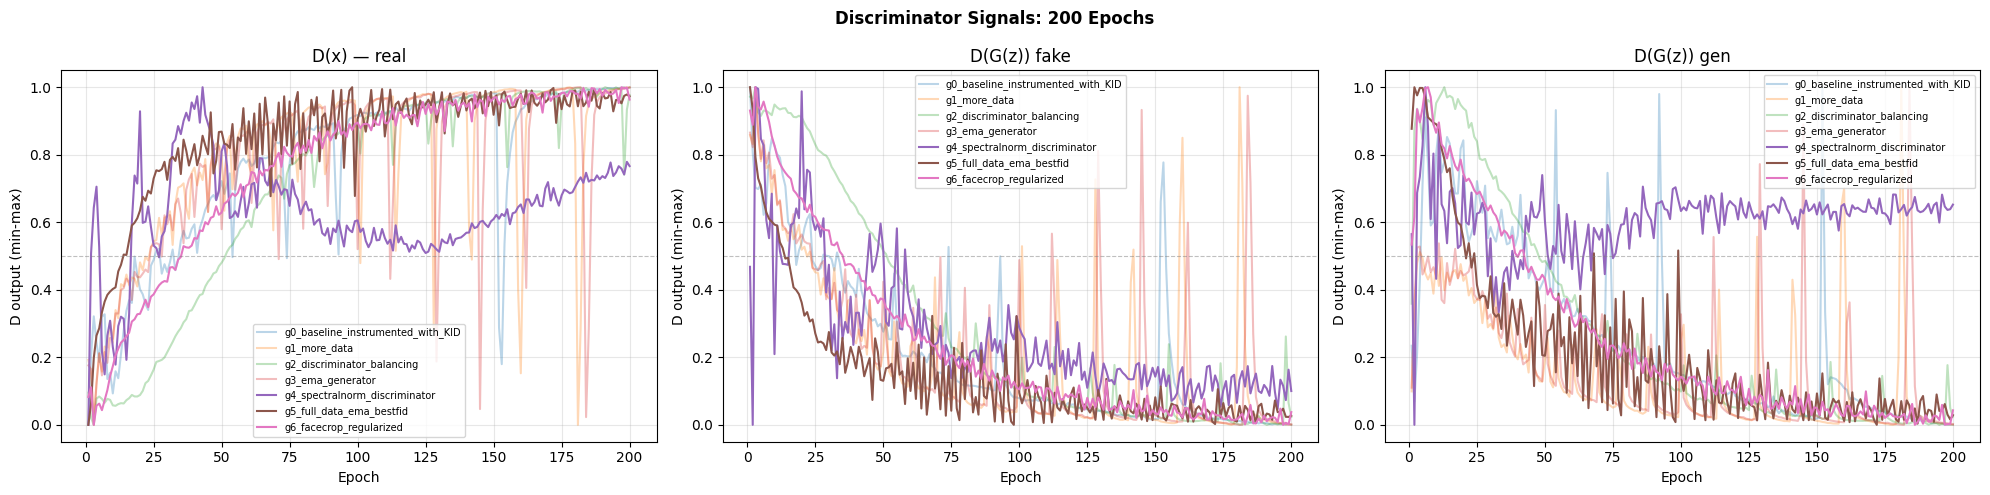

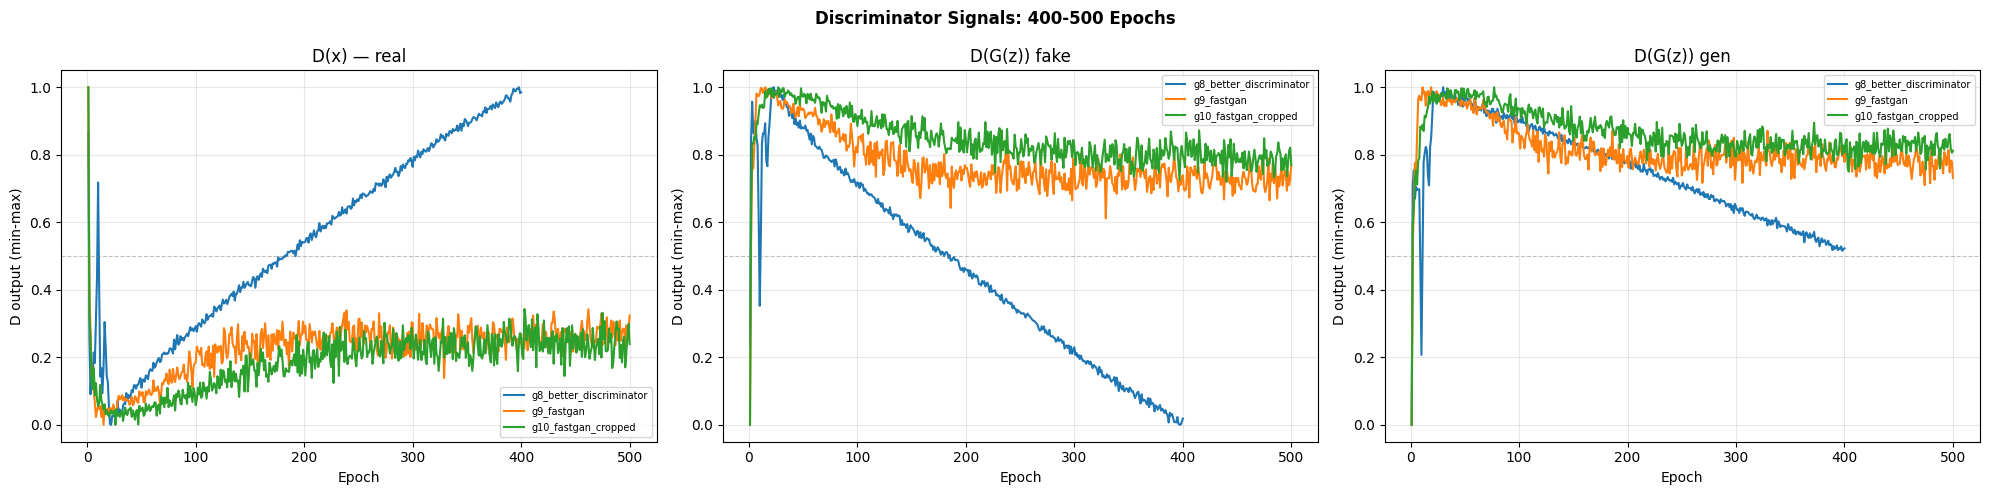

In [34]:
signals       = ["D_x", "D_G_z_fake", "D_G_z_gen"]
signal_labels = ["D(x) — real", "D(G(z)) fake", "D(G(z)) gen"]

for group, subtitle in zip(groups, subtitles):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle(f"Discriminator Signals: {subtitle}", fontsize=12, fontweight="bold")

    for (key, (df_metrics, df_train)), color in zip(group, colors):
        alpha = get_alpha(key)
        for ax, signal in zip(axes, signals):
            ax.plot(df_train["epoch"], minmax(df_train[signal]), label=full_name[key], color=color, alpha=alpha)

    for ax, sig_label in zip(axes, signal_labels):
        ax.set_title(sig_label); ax.set_xlabel("Epoch"); ax.set_ylabel("D output (min-max)")
        ax.axhline(0.5, linestyle="--", color="gray", alpha=0.5, linewidth=0.8)
        ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()

<span style="color:red"> WARNING </span>: FID and KID were not scaled due to low volume of values causing jittery lines! Additionally, no need to dim colors here. 

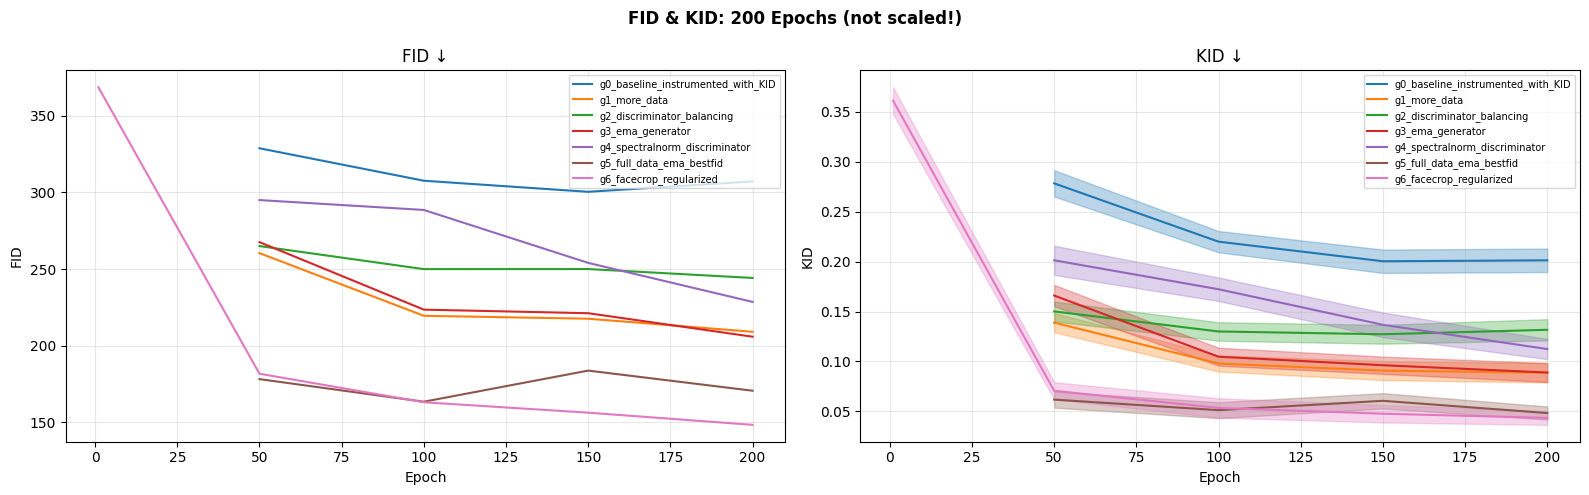

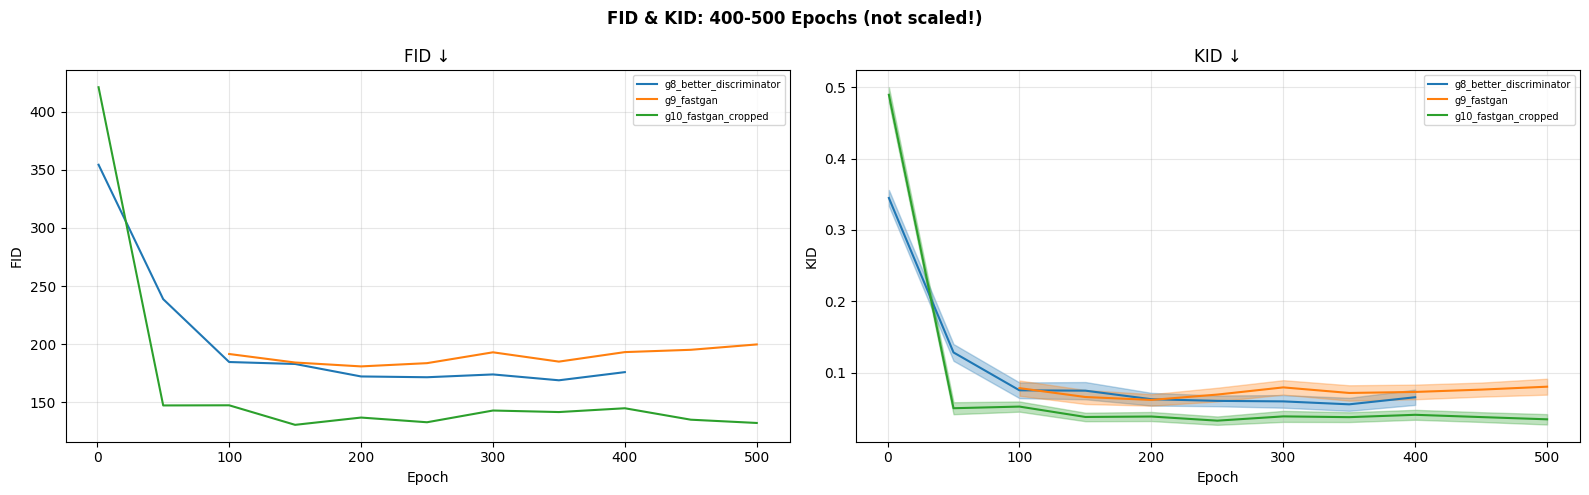

In [35]:
for group, subtitle in zip(groups, subtitles):
    fig, (ax_fid, ax_kid) = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f"FID & KID: {subtitle} (not scaled!)", fontsize=12, fontweight="bold")

    for (key, (df_metrics, df_train)), color in zip(group, colors):
        alpha = 1.0
        df_ema = df_metrics[df_metrics["evaluated_model"] == "ema"] if "evaluated_model" in df_metrics.columns else df_metrics

        ax_fid.plot(df_ema["epoch"], (df_ema["fid"]), label=full_name[key], color=color, alpha=alpha)
        ax_kid.plot(df_ema["epoch"], (df_ema["kid_mean"]), label=full_name[key], color=color, alpha=alpha)
        ax_kid.fill_between(
            df_ema["epoch"],
            (df_ema["kid_mean"]) - df_ema["kid_std"],
            (df_ema["kid_mean"]) + df_ema["kid_std"],
            alpha=alpha * 0.3, color=color
        )

    ax_fid.set_title("FID ↓"); ax_fid.set_xlabel("Epoch"); ax_fid.set_ylabel("FID")
    ax_fid.legend(fontsize=7); ax_fid.grid(True, alpha=0.3)
    ax_kid.set_title("KID ↓"); ax_kid.set_xlabel("Epoch"); ax_kid.set_ylabel("KID")
    ax_kid.legend(fontsize=7); ax_kid.grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()

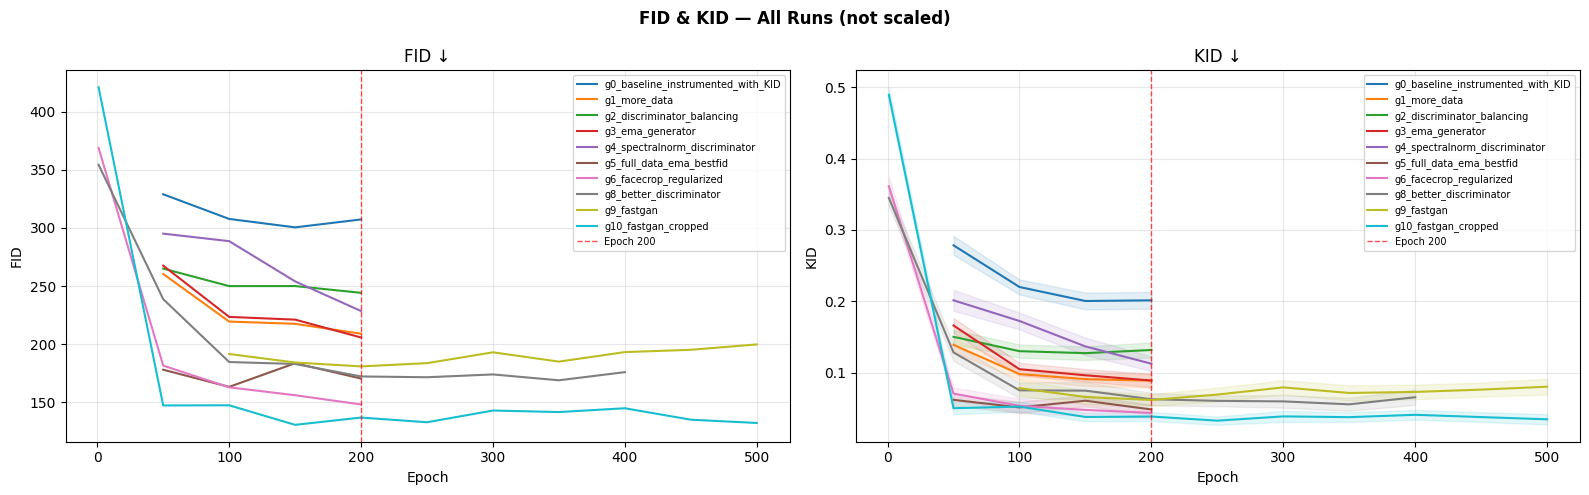

In [36]:
fig, (ax_fid, ax_kid) = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("FID & KID — All Runs (not scaled)", fontsize=12, fontweight="bold")

for (key, (df_metrics, df_train)), color in zip(all_items, colors):
    df_ema = df_metrics[df_metrics["evaluated_model"] == "ema"] if "evaluated_model" in df_metrics.columns else df_metrics

    ax_fid.plot(df_ema["epoch"], df_ema["fid"], label=full_name[key], color=color)
    ax_kid.plot(df_ema["epoch"], df_ema["kid_mean"], label=full_name[key], color=color)
    ax_kid.fill_between(
        df_ema["epoch"],
        df_ema["kid_mean"] - df_ema["kid_std"],
        df_ema["kid_mean"] + df_ema["kid_std"],
        alpha=0.12, color=color
    )

for ax in (ax_fid, ax_kid):
    ax.axvline(200, linestyle="--", color="red", linewidth=1.0, alpha=0.7, label="Epoch 200")

ax_fid.set_title("FID ↓"); ax_fid.set_xlabel("Epoch"); ax_fid.set_ylabel("FID")
ax_fid.legend(fontsize=7); ax_fid.grid(True, alpha=0.3)
ax_kid.set_title("KID ↓"); ax_kid.set_xlabel("Epoch"); ax_kid.set_ylabel("KID")
ax_kid.legend(fontsize=7); ax_kid.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()